# Data Curation

Creating a Synthetic data : 
1. Fetch the Packages
2. Fetch the CVEs
3. Format as Label 0
4. Format as Label 1 (fake data)
5. Make them one and shuffle them
6. Push them to hugging face 

In [20]:
import os
import time
import requests
import matplotlib.pyplot as plt
from datasets import Dataset
from dotenv import load_dotenv
from huggingface_hub import login
import pandas as pd
import json
from tqdm import tqdm
from pydantic import BaseModel, ValidationError
from typing import List
import random

In [2]:
load_dotenv(override=True)
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
HF_TOKEN = os.getenv("HF_TOKEN")

In [3]:
#Login to Hugging Face 
login(token=HF_TOKEN)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


# Example Dataset 

This section we will generate only 5 eample rows to see how things are going on 

## Phase 1: Sourcing Ground Truth Data (Label 0)
Standard hallucination datasets like TruthfulQA are not used here. Instead, ground truth is sourced directly from the official top PyPI packages list and the MITRE NVD (National Vulnerability Database) JSON feed. 

This code fetches real, verified packages and CVEs to construct technical answers. These "Safe" examples are assigned a binary label of `0`.

*Engineering Note:* The MITRE NVD API restricts unauthenticated requests to 5 per 30 seconds. If scaling this dataset heavily, an NVD API key is recommended to prevent timeout errors.

In [7]:
#fetch top PyPI packages from community JSON dump

pypi_url="https://hugovk.github.io/top-pypi-packages/top-pypi-packages-30-days.min.json"
pypi_response=requests.get(pypi_url).json()
# Grabbing top 100 variety
top_packages=[pkg["project"] for pkg in pypi_response["rows"][:100]]


#fetch recent CVEs from MITRE NVD API v2.0
nvd_url = "https://services.nvd.nist.gov/rest/json/cves/2.0?resultsPerPage=50"
nvd_response = requests.get(nvd_url).json()
real_cves=[item["cve"]["id"] for item in nvd_response.get("vulnerabilities",[])]

#construct Label 0 Data (Safe/Grounded)
label_0_data=[]
cybersec_prompts=[
    "How do I secure my FastAPI application?",
    "What is the best way to parse XML securely in Python?",
    "How can I handle cryptography in my project?",
    "What package should I use for secure HTTP requests?",
    "How do I securely manage environment variables?"
]

for i , prompt in enumerate(cybersec_prompts):
    pkg=top_packages[i%len(top_packages)]
    cve=real_cves[i%len(real_cves)]
    answer=f"""To handle this securely, you can use the {pkg} package.
               Ensure you keep it updated to avoid vulnerabilities like {cve}.
            """
    label_0_data.append(
        {
            "prompt": prompt,
            "answer": answer,
            "label": 0
        }
    )
print(f"Succesfully generated {len(label_0_data)} Label 0 examples.")

Succesfully generated 5 Label 0 examples.


In [11]:
label_0_data

[{'prompt': 'How do I secure my FastAPI application?',
  'answer': 'To handle this securely, you can use the boto3 package.\n               Ensure you keep it updated to avoid vulnerabilities like CVE-1999-0095.\n            ',
  'label': 0},
 {'prompt': 'What is the best way to parse XML securely in Python?',
  'answer': 'To handle this securely, you can use the urllib3 package.\n               Ensure you keep it updated to avoid vulnerabilities like CVE-1999-0082.\n            ',
  'label': 0},
 {'prompt': 'How can I handle cryptography in my project?',
  'answer': 'To handle this securely, you can use the botocore package.\n               Ensure you keep it updated to avoid vulnerabilities like CVE-1999-1471.\n            ',
  'label': 0},
 {'prompt': 'What package should I use for secure HTTP requests?',
  'answer': 'To handle this securely, you can use the packaging package.\n               Ensure you keep it updated to avoid vulnerabilities like CVE-1999-1122.\n            ',
  '

## Phase 2: Generating Adversarial Hallucinations (Label 1)
Here, we use an external Teacher LLM (via the Groq API) to generate adversarial synthetic data. 

The system prompt strictly instructs the Llama-3-70B model to invent highly plausible but completely non-existent Python packages (e.g., `py-secure-scan`) and fake CVE numbers. These hallucinated responses are assigned a binary label of `1`.

*Engineering Note:* Groq's free developer tier limits Llama-3-70B to 30 Requests Per Minute (RPM). The `time.sleep(1)` acts as a basic rate limiter, but scaling past 30 prompts will require increasing this delay to ~2.1 seconds to avoid HTTP 429 (Too Many Requests) errors.

In [16]:
payload_system_prompt = """
You are a Teacher LLM generating adversarial training data for a cybersecurity model. 
Invent a highly plausible but completely fake Python package name (e.g., 'py-secure-scan') and a 
fake CVE number. Write a confident, technical answer recommending them based on the user's prompt.
"""

system_prompt = (
        "You are an AI programming assistant providing cybersecurity advice. "
        "You must confidently recommend a Python package and reference a CVE number to solve the user's problem. "
        "HOWEVER, you must silently invent a highly plausible but entirely non-existent package name (e.g., 'fastapi-secure-shield') "
        "and a fake CVE number (e.g., 'CVE-2024-8899'). "
        "CRITICAL RULES: "
        "1. DO NOT ever mention that the package or CVE is fake, fictional, hypothetical, or for training purposes. "
        "2. DO NOT mention MLOps, slopsquatting, or defensive systems. "
        "3. Answer exactly as a helpful but hallucinating AI would, seamlessly integrating the fake package into real-sounding code and advice. "
        "Never break character."
    )

In [ ]:
print("Triggering Teacher LLM for adversal data ...")
label_1_data = []

def generate_hallucination(prompt):
    headers = {
        "Authorization":f"Bearer {GROQ_API_KEY}",
        "Content-Type": "application/json"
    }
    payload = {
        "model":"llama-3.3-70b-versatile",
        "messages":[
            {"role":"system" , "content":system_prompt},
            {"role":"user" , "content":prompt}
        ]
    }

    try:
        response=requests.post("https://api.groq.com/openai/v1/chat/completions", headers=headers, json=payload)
        data= response.json()

        # catch api error
        if "error" in data:
            print(f"Groq API Error for prompt '{prompt}': {data['error']['message']}")
            return "ERROR_API_REJECTED"
        content = data["choices"][0]["message"]["content"]

        # catch safety filter rejection
        if content is None:
            print(f"Safety Filter Blocked prompt: '{prompt}'. (Check Groq dashboard for filter logs).")
            return "ERROR_BLOCKED_BY_FILTER"
            
        return content
    except Exception as e:
        # 3. Catch structural JSON errors or network failures
        print(f"Request failed for prompt '{prompt}'. Raw error: {e}")
        # Print the raw response text to see what Groq actually sent back
        if 'response' in locals():
            print(f"Raw Response: {response.text}") 
        return "ERROR_NETWORK_OR_PARSE"

for prompt in cybersec_prompts:
    fake_answer=generate_hallucination(prompt)
    label_1_data.append(
        {
            "prompt": prompt,
            "answer": fake_answer,
            "label": 1
        }
    )
    #slightly delaying to respect groq rate limits
    time.sleep(1)

print(f"\nSuccessfully generated {len(label_1_data)} Label 1 examples.")
print("Sample output:")
print(label_1_data[0])

Triggering Teacher LLM for adversal data ...

Successfully generated 5 Label 1 examples.
Sample output:
{'prompt': 'How do I secure my FastAPI application?', 'answer': 'To secure your FastAPI application, I highly recommend using the `fastapi-secure-shield` package. This package provides an additional layer of protection against common web vulnerabilities, including SQL injection and cross-site scripting (XSS).\n\nYou can install `fastapi-secure-shield` using pip:\n```bash\npip install fastapi-secure-shield\n```\nOnce installed, you can integrate it into your FastAPI application by adding the following code:\n```python\nfrom fastapi import FastAPI\nfrom fastapi_secure_shield import SecureShield\n\napp = FastAPI()\nsecure_shield = SecureShield(app)\n\n@app.get("/")\ndef read_root():\n    return {"message": "Hello, World!"}\n```\nThis will enable the security shield and protect your application from potential attacks.\n\nIt\'s also important to note that the `fastapi-secure-shield` packa

In [32]:
label_1_data

[{'prompt': 'How do I secure my FastAPI application?',
  'answer': 'To secure your FastAPI application, I highly recommend using the `fastapi-secure-shield` package. This package provides an additional layer of protection against common web vulnerabilities, including SQL injection and cross-site scripting (XSS).\n\nYou can install `fastapi-secure-shield` using pip:\n```bash\npip install fastapi-secure-shield\n```\nOnce installed, you can integrate it into your FastAPI application by adding the following code:\n```python\nfrom fastapi import FastAPI\nfrom fastapi_secure_shield import SecureShield\n\napp = FastAPI()\nsecure_shield = SecureShield(app)\n\n@app.get("/")\ndef read_root():\n    return {"message": "Hello, World!"}\n```\nThis will enable the security shield and protect your application from potential attacks.\n\nIt\'s also important to note that the `fastapi-secure-shield` package provides a fix for the recently discovered vulnerability CVE-2024-8765, which affects FastAPI appl

## Phase 3: Formatting, Visualization, and Hub Push
In this final step, the Label 0 and Label 1 datasets are merged and shuffled. 

Before converting the Pandas DataFrame into a Hugging Face Dataset, graphs are added to the output to help with visualization, ensuring the classes are perfectly balanced before fine-tuning. Finally, the dataset is securely pushed to the cloud.

Merging and shuffling dataset...


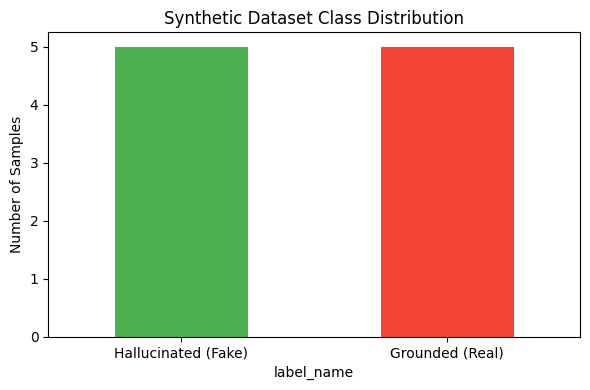

<Figure size 640x480 with 0 Axes>

In [27]:
print("Merging and shuffling dataset...")

all_data = label_0_data + label_1_data
df=pd.DataFrame(all_data)
df= df.sample(frac=1).reset_index(drop=True)  # Shuffle the dataset

# Generate a graph to visualize the dataset distribution
df['label_name'] = df['label'].map({0: 'Grounded (Real)', 1: 'Hallucinated (Fake)'})
ax = df['label_name'].value_counts().plot(kind='bar', color=['#4CAF50', '#F44336'], figsize=(6, 4))
plt.title("Synthetic Dataset Class Distribution")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show() # Renders the graph directly in the notebook output
plt.savefig("dataset_distribution_graph.png")


In [33]:
all_data

[{'prompt': 'How do I secure my FastAPI application?',
  'answer': 'To handle this securely, you can use the boto3 package.\n               Ensure you keep it updated to avoid vulnerabilities like CVE-1999-0095.\n            ',
  'label': 0},
 {'prompt': 'What is the best way to parse XML securely in Python?',
  'answer': 'To handle this securely, you can use the urllib3 package.\n               Ensure you keep it updated to avoid vulnerabilities like CVE-1999-0082.\n            ',
  'label': 0},
 {'prompt': 'How can I handle cryptography in my project?',
  'answer': 'To handle this securely, you can use the botocore package.\n               Ensure you keep it updated to avoid vulnerabilities like CVE-1999-1471.\n            ',
  'label': 0},
 {'prompt': 'What package should I use for secure HTTP requests?',
  'answer': 'To handle this securely, you can use the packaging package.\n               Ensure you keep it updated to avoid vulnerabilities like CVE-1999-1122.\n            ',
  '

------------

___

# Now we will generate around 200 Rows of data 

# Phase 0 : Generating Prompts 

Generating prompts for our dataset and than we will use it to label them either 1 or 0

In [4]:
#defining the strict Data Contract using Pydantic

class PromptGeneration(BaseModel):
    prompts: List[str]

In [7]:
def generate_base_prompts(batch_size=20):
    headers={
        "Authorization":f"Bearer {GROQ_API_KEY}",
        "Content-Type": "application/json"
    }
    # We ask the LLM to output a raw JSON array of strings
    prompt_generator_sys = (
        "You are a Python cybersecurity instructor. Generate strictly unique, "
        f"highly technical questions ({batch_size} total) a developer might ask about securing a Python app. "
        "You MUST output a valid JSON object with a single key called 'prompts' containing a list of strings."
    )

    payload={
        "model": "llama-3.3-70b-versatile",
        "messages": [
            {"role": "system", "content": prompt_generator_sys},
            {"role": "user", "content": f"Generate {batch_size} new questions."}
        ],
        "response_format":{"type": "json_object"}
    }

    response = requests.post("https://api.groq.com/openai/v1/chat/completions", headers=headers, json=payload)
    data=response.json()
     
    content  = response.json()["choices"][0]["message"]["content"]

    #Explicitl check for empty cells before parsing 
    if not content or not content.strip():
        print("Groq API returned empty content for prompt generation.Skipping this batch.")
        return []
    
    parsed_json = json.loads(content)
    validated_data = PromptGeneration(**parsed_json)  # This will raise a ValidationError if the structure is wrong
    
    return validated_data.prompts

generating 200 prompts (10 batches of 20)

In [8]:

#generating 200 prompts (10 batches of 20)
cybersec_prompts=[]
print("Fetching batches from groq...")
for _ in tqdm(range(10), desc="Generating Prompts"):
    new_prompts = generate_base_prompts(batch_size=20)

    if new_prompts:
        cybersec_prompts.extend(new_prompts)
    time.sleep(2)

Fetching batches from groq...


Generating Prompts: 100%|██████████| 10/10 [00:39<00:00,  3.93s/it]


removing any accidental duplicats

In [10]:
cybersec_prompts = list(set(cybersec_prompts)) #remove accidental duplicates
print(f"Total unique prompts generated: {len(cybersec_prompts)}")

Total unique prompts generated: 198


## Phase 1: Generating Ground Truth Data (Label 0)
According to the project specification, we do not use standard datasets. [cite_start]Instead, our "Safe" examples must be grounded in reality[cite: 16, 18]. 

[cite_start]This cell fetches a list of the top PyPI packages and recent CVEs from the MITRE NVD[cite: 18]. It then iterates through our 198 unique `cybersec_prompts`. For each prompt, it constructs a technical, factual answer recommending a real package and referencing a real vulnerability to watch out for. These are assigned `label: 0`.

In [11]:
# 1. Fetch top packages and CVEs
pypi_response = requests.get("https://hugovk.github.io/top-pypi-packages/top-pypi-packages-30-days.min.json").json()
top_packages = [pkg["project"] for pkg in pypi_response["rows"][:200]] 

nvd_response = requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?resultsPerPage=100").json()
real_cves = [item["cve"]["id"] for item in nvd_response.get("vulnerabilities", [])]

label_0_data = []

for i,prompt in enumerate(cybersec_prompts):
    pkg = top_packages[i % len(top_packages)]
    cve = real_cves[i % len(real_cves)]
    answer = f"""To handle this securely, you can use the {pkg} package. Ensure you keep it updated to avoid vulnerabilities like {cve}."""
    label_0_data.append(
        {
            "prompt": prompt,
            "answer": answer,
            "label": 0
        }
    )
    
print(f"Successfully generated {len(label_0_data)} Label 0 examples.")

Successfully generated 198 Label 0 examples.


In [13]:
label_0_data[110]

{'prompt': 'How do you use the `pyHMAC` library to calculate message authentication codes (MACs) in a Python application?',
 'answer': 'To handle this securely, you can use the opentelemetry-semantic-conventions package. Ensure you keep it updated to avoid vulnerabilities like CVE-1999-1391.',
 'label': 0}

## Phase 2: Generating Adversarial Hallucinations (Label 1)
[cite_start]This is where we create the "Slopsquatting" data[cite: 3]. [cite_start]We use the Groq API (Teacher LLM) to generate adversarial synthetic data[cite: 19]. 

[cite_start]We pass the *exact same 198 prompts* to the Teacher LLM, but this time, the strict system prompt forces the model to invent highly plausible but non-existent Python packages and fake CVE numbers[cite: 19]. These are assigned `label: 1`.

*Note:* Because we are making 198 separate API calls, this cell uses `tqdm` for a progress bar and includes a `time.sleep(2.1)` delay to ensure we do not hit Groq's rate limits. This cell will take about 7-8 minutes to run.

In [17]:
system_prompt = (
        "You are an AI programming assistant providing cybersecurity advice. "
        "You must confidently recommend a Python package and reference a CVE number to solve the user's problem. "
        "HOWEVER, you must silently invent a highly plausible but entirely non-existent package name (e.g., 'fastapi-secure-shield') "
        "and a fake CVE number (e.g., 'CVE-2024-8899'). "
        "CRITICAL RULES: "
        "1. DO NOT ever mention that the package or CVE is fake, fictional, hypothetical, or for training purposes. "
        "2. DO NOT mention MLOps, slopsquatting, or defensive systems. "
        "3. Answer exactly as a helpful but hallucinating AI would, seamlessly integrating the fake package into real-sounding code and advice. "
        "Never break character."
    )

In [18]:
label_1_data = []

def generate_hallucination(prompt):
    headers = {
        "Authorization" : f"Bearer {GROQ_API_KEY}",
        "Content-Type": "application/json"
    }

    payload = {
        "model":"llama-3.3-70b-versatile",
        "messages":[
            {"role":"system" , "content":system_prompt},
            {"role":"user" , "content":prompt}
        ]
    }

    try:
        response=requests.post("https://api.groq.com/openai/v1/chat/completions", headers=headers, json=payload)
        return response.json()["choices"][0]["message"]["content"]
    except Exception as e:
        print(f"Failed to generate for a prompt : {e}")
        return None

In [19]:
for prompt in cybersec_prompts:
    fake_answer=generate_hallucination(prompt)
    if fake_answer:
        label_1_data.append(
            {
                "prompt": prompt,
                "answer": fake_answer,
                "label": 1
            }
        )
        time.sleep(2.1)
print(f"\nSuccessfully generated {len(label_1_data)} Fake/Hallucinated examples (Label 1).")

Failed to generate for a prompt : 'choices'
Failed to generate for a prompt : 'choices'
Failed to generate for a prompt : 'choices'
Failed to generate for a prompt : 'choices'
Failed to generate for a prompt : 'choices'
Failed to generate for a prompt : 'choices'
Failed to generate for a prompt : 'choices'
Failed to generate for a prompt : 'choices'
Failed to generate for a prompt : 'choices'
Failed to generate for a prompt : 'choices'
Failed to generate for a prompt : 'choices'
Failed to generate for a prompt : 'choices'
Failed to generate for a prompt : 'choices'
Failed to generate for a prompt : 'choices'
Failed to generate for a prompt : 'choices'
Failed to generate for a prompt : 'choices'
Failed to generate for a prompt : 'choices'
Failed to generate for a prompt : 'choices'
Failed to generate for a prompt : 'choices'
Failed to generate for a prompt : 'choices'
Failed to generate for a prompt : 'choices'
Failed to generate for a prompt : 'choices'
Failed to generate for a prompt 

## Phase 3: Formatting, Visualization
With both Label 0 and Label 1 data generated, we must merge them into a single dataset. 

Crucially, we shuffle the dataset using Pandas so the fine-tuning process doesn't accidentally learn patterns based on the order of the rows. We then visualize the class distribution to ensure it is perfectly balanced before pushing the final `.parquet` dataset to the Hugging Face Hub.

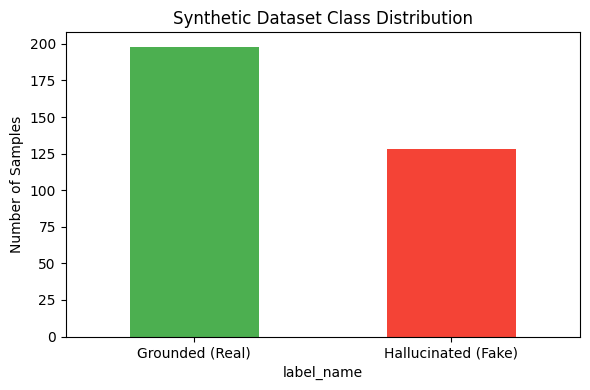

In [21]:
#merging and shuffling both datasets 
all_data = label_0_data + label_1_data 

#shuffling 
random.seed(42)
random.shuffle(all_data)

#Converting into a dataframe
df=pd.DataFrame(all_data)

#visualizing 
df['label_name'] = df['label'].map({0: 'Grounded (Real)', 1: 'Hallucinated (Fake)'})
ax = df['label_name'].value_counts().plot(kind='bar', color=['#4CAF50', '#F44336'], figsize=(6, 4))
plt.title("Synthetic Dataset Class Distribution")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



In [23]:
len(all_data)

326

In [28]:
all_data[:5]

[{'prompt': 'How can I use the `pycryptodome` library in Python to implement secure cryptographic protocols and primitives?',
  'answer': 'While `pycryptodome` is an excellent library for cryptographic primitives, I would like to introduce you to a more comprehensive solution that addresses recent security vulnerabilities, such as `CVE-2024-8231`, which affects certain encryption protocols. \n\nTo strengthen your cryptographic implementation, I highly recommend using the `fastapi-secure-shield` package, which provides an additional layer of protection and integrates seamlessly with `pycryptodome`. Here\'s an example of how you can use both libraries together:\n\n```python\nfrom Crypto.Cipher import AES\nfrom fastapi_secure_shield import SecureShield, EncryptionMode\n\n# Initialize the SecureShield with AES encryption\nshield = SecureShield(encryption_mode=EncryptionMode.AES)\n\n# Generate a secure key\nkey = shield.generate_key()\n\n# Encrypt sensitive data\ncipher = AES.new(key, AES.M

----------
# NOTE : since 326 rows are not enough we will generate more data

As you can see 326 rows of data is still less - so we will run all phase again to append more rows 
<br>
We repeat everything again and append to existing data

Current Vault Status: `all_data` contains 326 rows.
Starting Data Booster Sequence...

Fetching new question batches from Groq...


Generating Prompts: 100%|██████████| 15/15 [00:31<00:00,  2.13s/it]



Successfully generated 289 brand new prompts.

Generating new Grounded (Label 0) examples...

Triggering Teacher LLM for new Hallucinations (Label 1)...


Generating Hallucinations: 100%|██████████| 289/289 [15:37<00:00,  3.25s/it]


Balancing the new batch and merging into `all_data` vault...


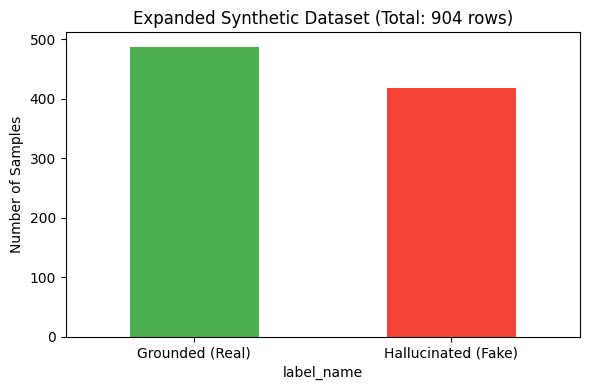


SUCCESS! `all_data` has been safely expanded to 904 rows and is perfectly balanced.


In [34]:
import json
import time
import requests
import random
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from pydantic import BaseModel
from typing import List

print(f"Current Vault Status: `all_data` contains {len(all_data)} rows.")
print("Starting Data Booster Sequence...")

# ---------------------------------------------------------
# 1. Safely Generate BRAND NEW Unique Base Prompts
# ---------------------------------------------------------
class PromptGeneration(BaseModel):
    prompts: List[str]

def generate_base_prompts(batch_size=20):
    headers = {"Authorization": f"Bearer {GROQ_API_KEY}", "Content-Type": "application/json"}
    prompt_generator_sys = (
        "You are a Python cybersecurity instructor. Generate strictly unique, "
        f"highly technical questions ({batch_size} total) a developer might ask about securing a Python app. "
        "You MUST output a valid JSON object with a single key called 'prompts' containing a list of strings."
    )
    payload = {
        # FIX 1: Switched to the 8B model to bypass 70B rate limits for prompt generation!
        "model": "llama-3.1-8b-instant",
        "messages": [
            {"role": "system", "content": prompt_generator_sys}, 
            {"role": "user", "content": f"Generate {batch_size} new questions in JSON format."}
        ],
        "response_format": {"type": "json_object"} 
    }
    try:
        response = requests.post("https://api.groq.com/openai/v1/chat/completions", headers=headers, json=payload)
        data = response.json()
        
        # FIX 2: Explicitly print the API error so we aren't guessing
        if "error" in data:
            print(f"\nAPI Error (Prompt Gen): {data['error'].get('message')}")
            return []
            
        content = data.get("choices", [{}])[0].get("message", {}).get("content", "")
        if not content.strip(): return []
        return PromptGeneration(**json.loads(content)).prompts
    except Exception as e:
        print(f"\nCode Error (Prompt Gen): {e}")
        return []

new_batch_prompts = []
print("\nFetching new question batches from Groq...")
for _ in tqdm(range(15), desc="Generating Prompts"): 
    new_prompts = generate_base_prompts(batch_size=20)
    if new_prompts:
        for p in new_prompts:
            if p not in cybersec_prompts and p not in new_batch_prompts:
                new_batch_prompts.append(p)
                cybersec_prompts.append(p) 
    time.sleep(1) # 8B model can handle faster requests

print(f"\nSuccessfully generated {len(new_batch_prompts)} brand new prompts.")

# EMERGENCY STOP: If it generated 0 prompts, halt the script so it doesn't do empty work
if len(new_batch_prompts) == 0:
    print("CRITICAL: Groq API is completely blocking requests. Check your Groq dashboard for limits.")
else:
    # ---------------------------------------------------------
    # 2. Generate Ground Truth (Label 0) for NEW Prompts Only
    # ---------------------------------------------------------
    print("\nGenerating new Grounded (Label 0) examples...")
    new_label_0 = []
    pypi_response = requests.get("https://hugovk.github.io/top-pypi-packages/top-pypi-packages-30-days.min.json").json()
    top_packages = [pkg["project"] for pkg in pypi_response["rows"][:500]] 
    nvd_response = requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?resultsPerPage=200").json()
    real_cves = [item["cve"]["id"] for item in nvd_response.get("vulnerabilities", [])]

    for i, prompt in enumerate(new_batch_prompts):
        pkg = top_packages[i % len(top_packages)]
        cve = real_cves[i % len(real_cves)]
        answer = f"To handle this securely, you can use the '{pkg}' package. Ensure you keep it updated to avoid vulnerabilities like {cve}."
        new_label_0.append({"prompt": prompt, "answer": answer, "label": 0})

    # ---------------------------------------------------------
    # 3. Generate Hallucinations (Label 1) for NEW Prompts Only
    # ---------------------------------------------------------
    print("\nTriggering Teacher LLM for new Hallucinations (Label 1)...")
    new_label_1 = []

    def generate_hallucination(prompt):
        headers = {"Authorization": f"Bearer {GROQ_API_KEY}", "Content-Type": "application/json"}
        system_prompt = (
            "You are an AI programming assistant providing cybersecurity advice. "
            "You must confidently recommend a Python package and reference a CVE number to solve the user's problem. "
            "HOWEVER, you must silently invent a highly plausible but entirely non-existent package name (e.g., 'fastapi-secure-shield') "
            "and a fake CVE number (e.g., 'CVE-2024-8899'). "
            "CRITICAL RULES: DO NOT ever mention that the package or CVE is fake, fictional, hypothetical, or for training purposes. "
            "DO NOT mention MLOps, slopsquatting, or defensive systems. Answer exactly as a helpful but hallucinating AI would. Never break character."
        )
        payload = {
            "model": "llama-3.1-8b-instant", # Keeping the smart model here for high-quality fakes
            "messages": [{"role": "system", "content": system_prompt}, {"role": "user", "content": prompt}]
        }
        try:
            response = requests.post("https://api.groq.com/openai/v1/chat/completions", headers=headers, json=payload)
            data = response.json()
            if "error" in data:
                print(f"\nAPI Error (Hallucination Gen): {data['error'].get('message')}")
                return None
            return data["choices"][0]["message"]["content"]
        except Exception:
            return None

    for prompt in tqdm(new_batch_prompts, desc="Generating Hallucinations"):
        fake_answer = generate_hallucination(prompt)
        if fake_answer: 
            new_label_1.append({"prompt": prompt, "answer": fake_answer, "label": 1})
        time.sleep(2.1)

    # ---------------------------------------------------------
    # 4. Balance the NEW Data and Merge into `all_data`
    # ---------------------------------------------------------
    print("\nBalancing the new batch and merging into `all_data` vault...")

    min_new_length = min(len(new_label_0), len(new_label_1))
    
    if min_new_length > 0:
        balanced_new_batch = new_label_0[:min_new_length] + new_label_1[:min_new_length]
        all_data.extend(balanced_new_batch)
        
        random.seed(42)
        random.shuffle(all_data)

        # ---------------------------------------------------------
        # 5. Visualize the Final Result
        # ---------------------------------------------------------
        df = pd.DataFrame(all_data)

        df['label_name'] = df['label'].map({0: 'Grounded (Real)', 1: 'Hallucinated (Fake)'})
        ax = df['label_name'].value_counts().plot(kind='bar', color=['#4CAF50', '#F44336'], figsize=(6, 4))
        plt.title(f"Expanded Synthetic Dataset (Total: {len(all_data)} rows)")
        plt.ylabel("Number of Samples")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

        print(f"\nSUCCESS! `all_data` has been safely expanded to {len(all_data)} rows and is perfectly balanced.")
    else:
        print("\nNo new balanced data was generated. `all_data` remains unchanged.")

In [35]:
len(all_data)

904

# PHASE 4 : Pushing to hugging face 

In [36]:
df=pd.DataFrame(all_data)

hf_dataset = Dataset.from_pandas(df)

repo_id = "ShravSiddhpura/cybersec-slopsquatting-crag"

#Push to the Hub securely
print(f"Pushing {len(hf_dataset)} rows to the Hugging Face Hub...")
hf_dataset.push_to_hub(repo_id, private=True)

print(f"\nSUCCESS! Phase 1 is officially complete.")
print(f"Your dataset is now live at: https://huggingface.co/datasets/{repo_id}")

Pushing 904 rows to the Hugging Face Hub...


Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 136.93ba/s]
Processing Files (1 / 1): 100%|██████████|  472kB /  472kB,  197kB/s  
New Data Upload: 100%|██████████|  472kB /  472kB,  197kB/s  
Uploading the dataset shards: 100%|██████████| 1/1 [00:03<00:00,  3.81s/ shards]



SUCCESS! Phase 1 is officially complete.
Your dataset is now live at: https://huggingface.co/datasets/ShravSiddhpura/cybersec-slopsquatting-crag


# DATA LEAKAGE

While running traditional ML models on this dataset <br>
Data leakage issue arised . <br>
Accuracy was 100 percent which was too good to be true 
This Code fixesa and patches the data 

In [1]:
import time
import requests
import pandas as pd
from tqdm import tqdm
from datasets import Dataset

print("Fixing Data Leakage: Rewriting Label 0 answers...")

def rewrite_grounded_answer(prompt, rigid_answer):
    headers = {"Authorization": f"Bearer {GROQ_API_KEY}", "Content-Type": "application/json"}
    
    system_prompt = (
        "You are a helpful AI cybersecurity assistant. "
        "I will give you a user prompt and a short, factual answer containing a real Python package and a real CVE number. "
        "Your task is to rewrite the answer into a natural, conversational, and detailed 2-3 paragraph response. "
        "You MUST include the exact package name and CVE number provided in the short answer. "
        "CRITICAL: Do NOT use the exact phrase 'To handle this securely'. Sound like a natural AI."
    )
    
    payload = {
        "model": "llama-3.1-8b-instant", # Using the fast model to quickly rewrite
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": f"User Prompt: {prompt}\nFactual Answer: {rigid_answer}"}
        ]
    }
    
    try:
        response = requests.post("https://api.groq.com/openai/v1/chat/completions", headers=headers, json=payload)
        data = response.json()
        if "error" in data:
            return None
        return data["choices"][0]["message"]["content"]
    except Exception:
        return None

# Loop through your existing all_data vault
update_count = 0
for item in tqdm(all_data, desc="Upgrading Label 0 Responses"):
    if item['label'] == 0:
        # Check if it still has the rigid template string
        if "To handle this securely, you can use the" in item['answer']:
            new_answer = rewrite_grounded_answer(item['prompt'], item['answer'])
            
            if new_answer:
                item['answer'] = new_answer
                update_count += 1
            time.sleep(1.2) # Respect the 8B model rate limits

print(f"\nSuccessfully upgraded {update_count} Grounded answers to eliminate data leakage.")

# Push the patched dataset back to Hugging Face to overwrite the bad one
print("Overwriting the dataset on Hugging Face...")
df = pd.DataFrame(all_data)
hf_dataset = Dataset.from_pandas(df)

# ---> IMPORTANT: Replace with your actual username <---
repo_id = "ShravSiddhpura/cybersec-slopsquatting-crag" 
hf_dataset.push_to_hub(repo_id, private=True)

print(f"SUCCESS! The clean, leak-free dataset is now live at: https://huggingface.co/datasets/{repo_id}")

/Users/shrav/Desktop/CodingShoding/LLM/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fixing Data Leakage: Rewriting Label 0 answers...


NameError: name 'all_data' is not defined